In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, roc_curve, auc, precision_recall_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print('✓ All libraries loaded successfully!')

✓ All libraries loaded successfully!


In [2]:
X, y = make_classification(
    n_samples=10000,
    n_features=20,
    n_informative=15,
    n_redundant=5,
    n_classes=2,
    weights=(0.99, 0.01),   # 99% legitimate, 1% fraud
    flip_y=0.01,
    random_state=42
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [7]:
print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("\nClass distribution in training set:")
print(f"Legitimate (0):, {np.sum(y_train == 0)} ({(np.mean(y_train == 0))*100:.1f}%)")
print(f"Fraud (1):, {np.sum(y_train == 1)} ({(np.mean(y_train == 1))*100:.1f}%)")
print(f"\nImbalance ratio:, {np.sum(y_train==0)/np.sum(y_train==1):.0f}:1")

Training set size: 7000
Test set size: 3000

Class distribution in training set:
Legitimate (0):, 6901 (98.6%)
Fraud (1):, 99 (1.4%)

Imbalance ratio:, 70:1


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [12]:
y_proba = model.predict_proba(X_test_scaled)[:,1] #p(class=0),p(class=1)
y_pred_default = model.predict(X_test_scaled)
y_proba

array([0.11550242, 0.07516705, 0.00720882, ..., 0.01185222, 0.00483965,
       0.00224383])

In [14]:
# Evaluate at default threshold
print("\nBASELINE MODEL (Threshold = 0.5)")

# 1. Accuracy
print(f"Accuracy: {model.score(X_test_scaled, y_test):.4f}")

# 2. Precision
print("Precision:", precision_score(y_test, y_pred_default, zero_division=0))

# 3. Recall
print("Recall:", recall_score(y_test, y_pred_default, zero_division=0))

# 4. F1 Score
print("F1 Score:", f1_score(y_test, y_pred_default, zero_division=0))

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_default).ravel()
print("\nConfusion Matrix:")
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)
print("------")


BASELINE MODEL (Threshold = 0.5)
Accuracy: 0.9880
Precision: 1.0
Recall: 0.14285714285714285
F1 Score: 0.25

Confusion Matrix:
True Negatives (TN): 2958
False Positives (FP): 0
False Negatives (FN): 36
True Positives (TP): 6
------


In [15]:
baseline = DummyClassifier(strategy='most_frequent') # Compares with baseline
baseline.fit(X_train_scaled, y_train)
baseline_pred = baseline.predict(X_test_scaled)

print("\n" + "#"*70)
print("BASELINE CHECK: Majority Class Predictor")
print("#"*70)

print("\nBaseline Model (Always Predict 'Legitimate'):")
print(f"  Accuracy: {baseline.score(X_test_scaled, y_test):.4f}")
print(f"  Recall on Fraud: {recall_score(y_test, baseline_pred, zero_division=0):.4f}")

print("\nYour Model (threshold = 0.5):")
print(f"  Accuracy: {model.score(X_test_scaled, y_test):.4f}")
print(f"  Recall on Fraud: {recall_score(y_test, y_pred_default, zero_division=0):.4f}")

if abs(model.score(X_test_scaled, y_test) - baseline.score(X_test_scaled, y_test)) < 0.01:
    print("\n⚠️ WARNING: Model performance ≈ baseline!")
    print("   → The model may be predicting majority class for everything.")
else:
    print("\n✅ Model outperforms baseline — learning signal detected.")



######################################################################
BASELINE CHECK: Majority Class Predictor
######################################################################

Baseline Model (Always Predict 'Legitimate'):
  Accuracy: 0.9860
  Recall on Fraud: 0.0000

Your Model (threshold = 0.5):
  Accuracy: 0.9880
  Recall on Fraud: 0.1429

⚠️ WARNING: Model performance ≈ baseline!
   → The model may be predicting majority class for everything.


In [17]:
thresholds = np.linspace(0,1,101) # Takes 100 values b/w 0 and 1
results = []
for threshold in thresholds:
  y_pred = (y_proba >= threshold).astype(int)
  # Calculate metrics
  precision = precision_score(y_test, y_pred, zero_division=0)
  recall = recall_score(y_test, y_pred, zero_division=0)
  f1 = f1_score(y_test, y_pred, zero_division=0)

  # Confusion matrix
  tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

  results.append({
      'threshold': threshold,
      'precision': precision,
      'recall': recall,
      'f1': f1,
      'tp': tp,
      'fp': fp,
      'fn': fn,
      'tn': tn
  })

results_df = pd.DataFrame(results)
results_df

,threshold,precision,recall,f1,tp,fp,fn,tn
0,0.00,0.014000,1.000000,0.027613,42,2958,0,0
1,0.01,0.030542,0.738095,0.058657,31,984,11,1974
2,0.02,0.053498,0.619048,0.098485,26,460,16,2498
3,0.03,0.081560,0.547619,0.141975,23,259,19,2699
4,0.04,0.120690,0.500000,0.194444,21,153,21,2805
...,...,...,...,...,...,...,...,...
96,0.96,0.000000,0.000000,0.000000,0,0,42,2958
97,0.97,0.000000,0.000000,0.000000,0,0,42,2958
98,0.98,0.000000,0.000000,0.000000,0,0,42,2958
99,0.99,0.000000,0.000000,0.000000,0,0,42,2958


In [18]:
max_f1_idx = results_df['f1'].idxmax()
optimal_f1_threshold = results_df.loc[max_f1_idx, 'threshold']
print("\n" + "#"*70)
print("THRESHOLD OPTIMIZATION")
print("#"*70)

print(f"Optimal threshold for F1 maximization: {optimal_f1_threshold:.2f}")
print(f"  F1 Score: {results_df.loc[max_f1_idx, 'f1']:.4f}")
print(f"  Precision: {results_df.loc[max_f1_idx, 'precision']:.4f}")
print(f"  Recall: {results_df.loc[max_f1_idx, 'recall']:.4f}")

print("#"*70)


######################################################################
THRESHOLD OPTIMIZATION
######################################################################
Optimal threshold for F1 maximization: 0.13
  F1 Score: 0.4308
  Precision: 0.6087
  Recall: 0.3333
######################################################################


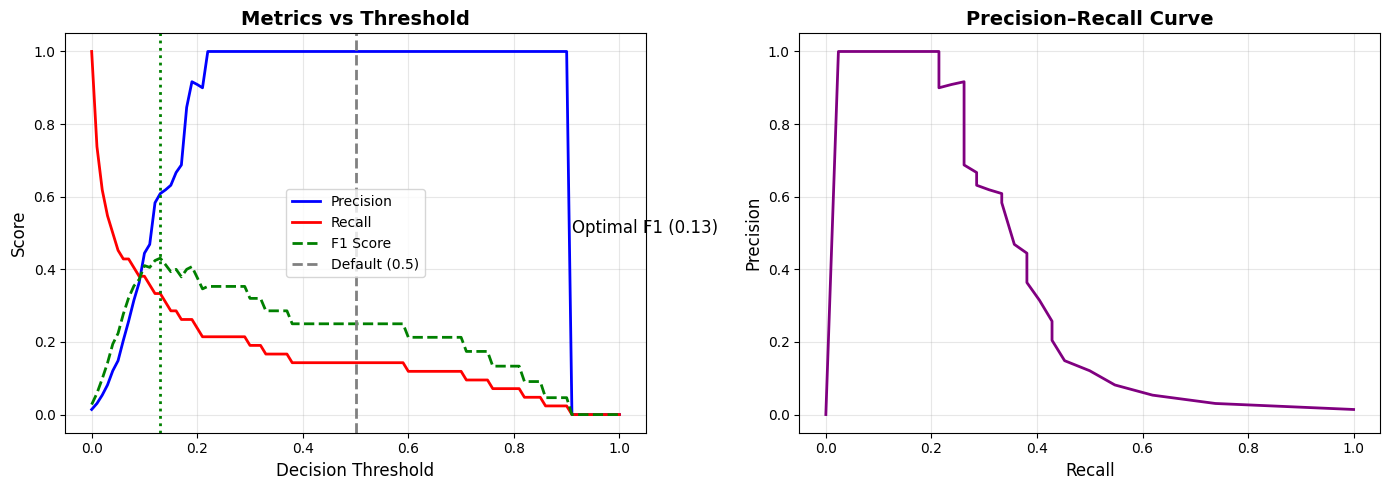

In [23]:
plt.figure(figsize=(14, 5))

# Plot 1: Precision and Recall vs Threshold
plt.subplot(1, 2, 1)
plt.plot(results_df['threshold'], results_df['precision'],
         label='Precision', linewidth=2, color='blue')
plt.plot(results_df['threshold'], results_df['recall'],
         label='Recall', linewidth=2, color='red')
plt.plot(results_df['threshold'], results_df['f1'],
         label='F1 Score', linewidth=2, color='green', linestyle='--')
plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)', linewidth=2)

plt.axvline(optimal_f1_threshold, color='green', linestyle=':', linewidth=2)
plt.text(0.91, 0.5, f"Optimal F1 ({optimal_f1_threshold:.2f})", fontsize=12)

plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metrics vs Threshold', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Precision–Recall Curve
plt.subplot(1, 2, 2)
plt.plot(results_df['recall'], results_df['precision'], linewidth=2, color='purple')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision–Recall Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
COST_FP = 10
COST_FN = 2000
print("\n" + "#"*70)
print("BUSINESS COST STRUCTURE")
print("#"*70)

print(f"False Positive (FP): ${COST_FP}  (blocked legitimate transaction)")
print(f"False Negative (FN): ${COST_FN}  (missed fraud)")
print(f"Cost Ratio (FN:FP): {COST_FN/COST_FP:.0f}:1")

print("#"*70)


######################################################################
BUSINESS COST STRUCTURE
######################################################################
False Positive (FP): $10  (blocked legitimate transaction)
False Negative (FN): $2000  (missed fraud)
Cost Ratio (FN:FP): 200:1
######################################################################


In [39]:
# Calculate total cost per threshold
results_df['total_cost'] = fp * COST_FP + fn * COST_FN
# Find min cost threshold
min_cost_idx = results_df['total_cost'].idxmin()
optimal_cost_threshold = results_df.loc[min_cost_idx, 'threshold']
min_total_cost = results_df.loc[min_cost_idx, 'total_cost']

default_cost = results_df[results_df['threshold'] == 0.5]['total_cost'].values[0]

print("\n" + "#"*70)
print("COST ANALYSIS")
print("#"*70)

print(f"Default threshold (0.5):")
print(f"  Total Cost: ${default_cost:,.0f}")

print(f"Optimal threshold ({optimal_cost_threshold:.2f}):")
print(f"  Total Cost: ${min_total_cost:,.0f}")

print(f"  FP: {results_df.loc[min_cost_idx, 'fp']:.0f}")
print(f"  FN: {results_df.loc[min_cost_idx, 'fn']:.0f}")

print(f"\n✅ Cost Savings: ${default_cost - min_total_cost:,.0f} ({(1 - min_total_cost/default_cost)*100:.1f}% reduction)")

print("#"*70)


######################################################################
COST ANALYSIS
######################################################################
Default threshold (0.5):
  Total Cost: $84,000
Optimal threshold (0.00):
  Total Cost: $84,000
  FP: 2958
  FN: 0

✅ Cost Savings: $0 (0.0% reduction)
######################################################################


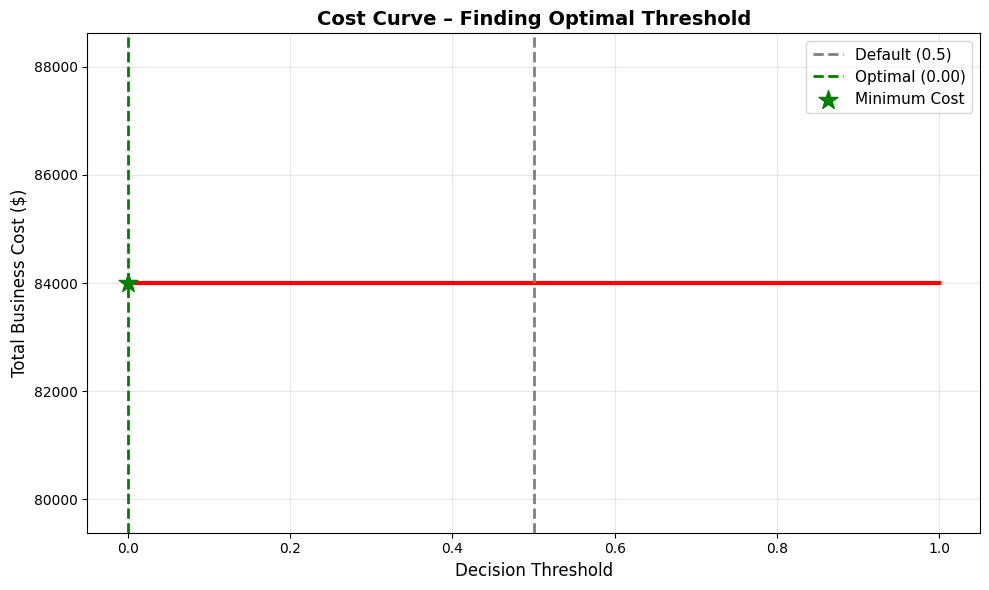

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['threshold'], results_df['total_cost'], linewidth=3, color='red')

plt.axvline(0.5, color='gray', linestyle='--', label='Default (0.5)', linewidth=2)

plt.axvline(optimal_cost_threshold, color='green', linestyle='--',
            label=f'Optimal ({optimal_cost_threshold:.2f})', linewidth=2)

plt.scatter([optimal_cost_threshold], [min_total_cost],
            color='green', s=200, zorder=5, marker='*', label='Minimum Cost')

plt.xlabel('Decision Threshold', fontsize=12)
plt.ylabel('Total Business Cost ($)', fontsize=12)
plt.title('Cost Curve – Finding Optimal Threshold', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [42]:
print("\n" + "#"*70)
print("SMOTE: SYNTHETIC MINORITY OVERSAMPLING")
print("#"*70)

print("\nBefore SMOTE:")
print(f"  Class distribution: {Counter(y_train)}")
print(f"  Imbalance ratio: {(np.sum(y_train==0) / np.sum(y_train==1)):.1f}:1")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE:")
print(f"  Class distribution: {Counter(y_train_smote)}")
print(f"  Dataset size: {len(y_train)} -> {len(y_train_smote)} (+{len(y_train_smote)-len(y_train)} samples)")


######################################################################
SMOTE: SYNTHETIC MINORITY OVERSAMPLING
######################################################################

Before SMOTE:
  Class distribution: Counter({np.int64(0): 6901, np.int64(1): 99})
  Imbalance ratio: 69.7:1

After SMOTE:
  Class distribution: Counter({np.int64(0): 6901, np.int64(1): 6901})
  Dataset size: 7000 -> 13802 (+6802 samples)


In [43]:
# Train model on SMOTE'd data
model_smote = LogisticRegression(max_iter=1000, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print("\nModel Performance (SMOTE):")
print(f"  Accuracy: {model_smote.score(X_test_scaled, y_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_smote):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_smote):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_smote):.4f}")

print("\nImprovement over Original:")
print(f"  Δ Recall: {recall_score(y_test, y_pred_smote) - recall_score(y_test, y_pred_default):.4f}")

print("#"*70)


Model Performance (SMOTE):
  Accuracy: 0.7820
  Precision: 0.0419
  Recall: 0.6667
  F1 Score: 0.0789

Improvement over Original:
  Δ Recall: 0.5238
######################################################################


In [44]:
print("#"*70)
print("\nRandom undersampling")
print("#"*70)

# Apply random undersampling
rus = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = rus.fit_resample(X_train_scaled, y_train)

print("\nAfter random undersampling")
print(f" Class distribution: {Counter(y_train_under)}")
print(f" Dataset size: {len(y_train)} -> {len(y_train_under)} ({len(y_train)-len(y_train_under)} samples removed)")

######################################################################

Random undersampling
######################################################################

After random undersampling
 Class distribution: Counter({np.int64(0): 99, np.int64(1): 99})
 Dataset size: 7000 -> 198 (6802 samples removed)


In [45]:
# Train model on undersampled data
model_under = LogisticRegression(max_iter=1000, random_state=42)
model_under.fit(X_train_under, y_train_under)
y_pred_under = model_under.predict(X_test_scaled)

print("\nModel Performance (Undersampling):")
print(f"  Accuracy: {model_under.score(X_test_scaled, y_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_under):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_under):.4f}")
print(f"  F1 Score: {f1_score(y_test, y_pred_under):.4f}")
print("#"*70)


Model Performance (Undersampling):
  Accuracy: 0.6740
  Precision: 0.0282
  Recall: 0.6667
  F1 Score: 0.0542
######################################################################
